In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('netflix_titles.csv')

In [8]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


The dataset contains information about Netflix Movies and TV Shows including title, director, cast, country, release year, rating, and duration.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Some columns in the dataset contain missing values. To make the analysis easier and more consistent, these missing values will be handled by replacing them with appropriate placeholders.

In [9]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

In [10]:
# Çok az eksik verisi olan satırları SİL (Drop Rows)
# date_added (10), rating (4) ve duration (3) için toplam ~17 satır silinecek.

df.dropna(subset=['date_added', 'rating', 'duration'], inplace=True)

In [11]:
# Sonuçları kontrol et
print("Eksik Değerlerin Güncel Durumu:")
print(df.isnull().sum())

Eksik Değerlerin Güncel Durumu:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [12]:
# Tarih verisini dönüştürme (Data Transformation) [cite: 2950]
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year

In [13]:
# Yeni sütunu ve güncel veri tiplerini görmek için
print(df[['date_added', 'year_added']].head())
print(df.info())

  date_added  year_added
0 2021-09-25        2021
1 2021-09-24        2021
2 2021-09-24        2021
3 2021-09-24        2021
4 2021-09-24        2021
<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   object        
 1   type          8790 non-null   object        
 2   title         8790 non-null   object        
 3   director      8790 non-null   object        
 4   cast          8790 non-null   object        
 5   country       8790 non-null   object        
 6   date_added    8790 non-null   datetime64[ns]
 7   release_year  8790 non-null   int64         
 8   rating        8790 non-null   object        
 9   duration      8790 non-null   object        
 10  listed_in     8790 non-null   object        
 11  description   8790 non-null   object        
 12  year_added    8790 non-null   int32        

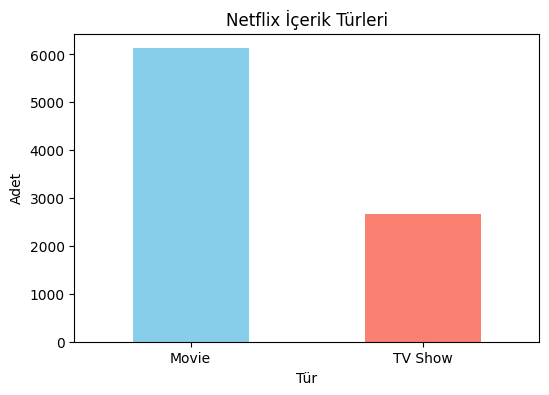

In [14]:
type_counts = df['type'].value_counts()
plt.figure(figsize=(6, 4))
type_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Netflix İçerik Türleri')
plt.xlabel('Tür')
plt.ylabel('Adet')
plt.xticks(rotation=0)
plt.show()

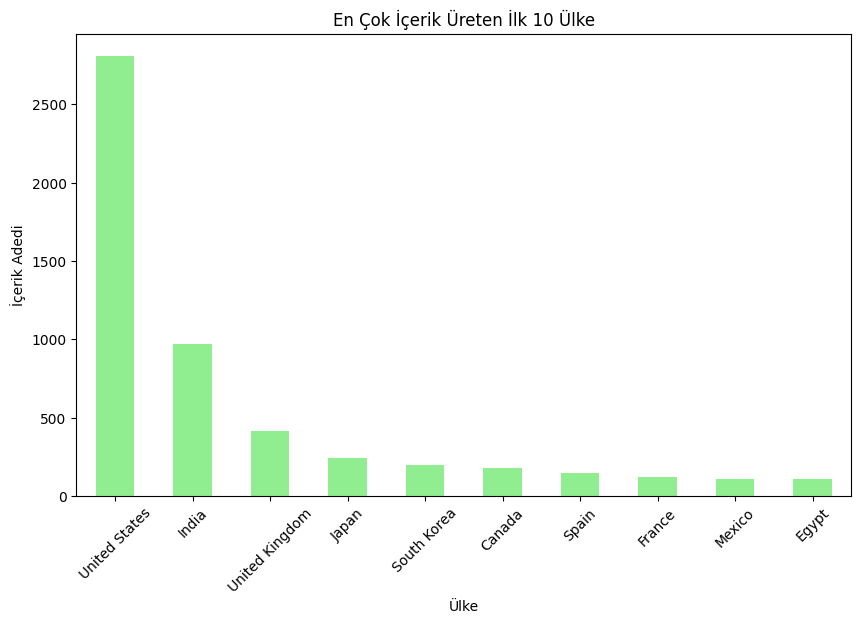

In [16]:
top_countries = df[df['country'] != "Unknown"]['country'].value_counts().head(10)
plt.figure(figsize=(10, 6))
top_countries.plot(kind='bar', color='lightgreen')
plt.title('En Çok İçerik Üreten İlk 10 Ülke')
plt.xlabel('Ülke')
plt.ylabel('İçerik Adedi')
plt.xticks(rotation=45)
plt.show()

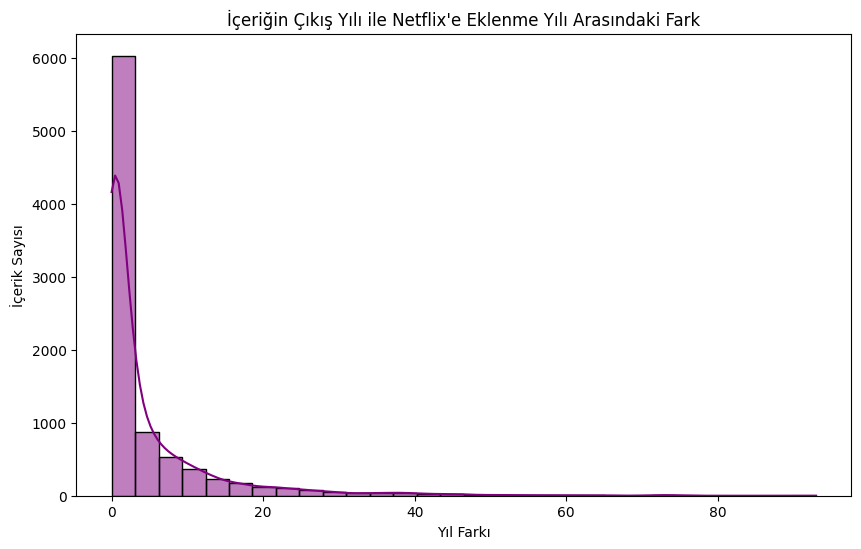

In [18]:
import seaborn as sns

# Yayın yılı ile eklenme yılı arasındaki farkı hesaplayalım
df['years_diff'] = df['year_added'] - df['release_year']

plt.figure(figsize=(10, 6))
sns.histplot(df[df['years_diff'] >= 0]['years_diff'], bins=30, kde=True, color='purple')
plt.title('İçeriğin Çıkış Yılı ile Netflix\'e Eklenme Yılı Arasındaki Fark')
plt.xlabel('Yıl Farkı')
plt.ylabel('İçerik Sayısı')
plt.show()

Bu grafik sana Netflix'in bir "arşiv" mi yoksa "güncel içerik platformu" mu olduğunu söyler.

Veri Dağılımı (Skewness): Grafik muhtemelen 0 değerinde devasa bir tepe yapacak. Bu, içeriklerin büyük çoğunluğunun çıktığı yıl Netflix'e eklendiğini gösterir. Bu da Netflix'in "Güncel/Orijinal İçerik" odaklı bir dev olduğunu kanıtlar .

Aykırı Değerler (Outliers): Farkın 40-50 olduğu küçük barlar göreceksin. Bunlar Netflix'in kütüphanesindeki "Klasik" içeriklerdir .


İş Değeri (Business Insight): Eğer bu fark yıllar geçtikçe azalıyorsa (yani grafik 0'a daha çok yaklaşıyorsa), Netflix'in lisans satın almaktan ziyade kendi içeriklerini (Netflix Originals) üretmeye kaydığını anlarız.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10852\1474203214.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='listed_in', y='duration_num', data=df_plot, palette='Set2')


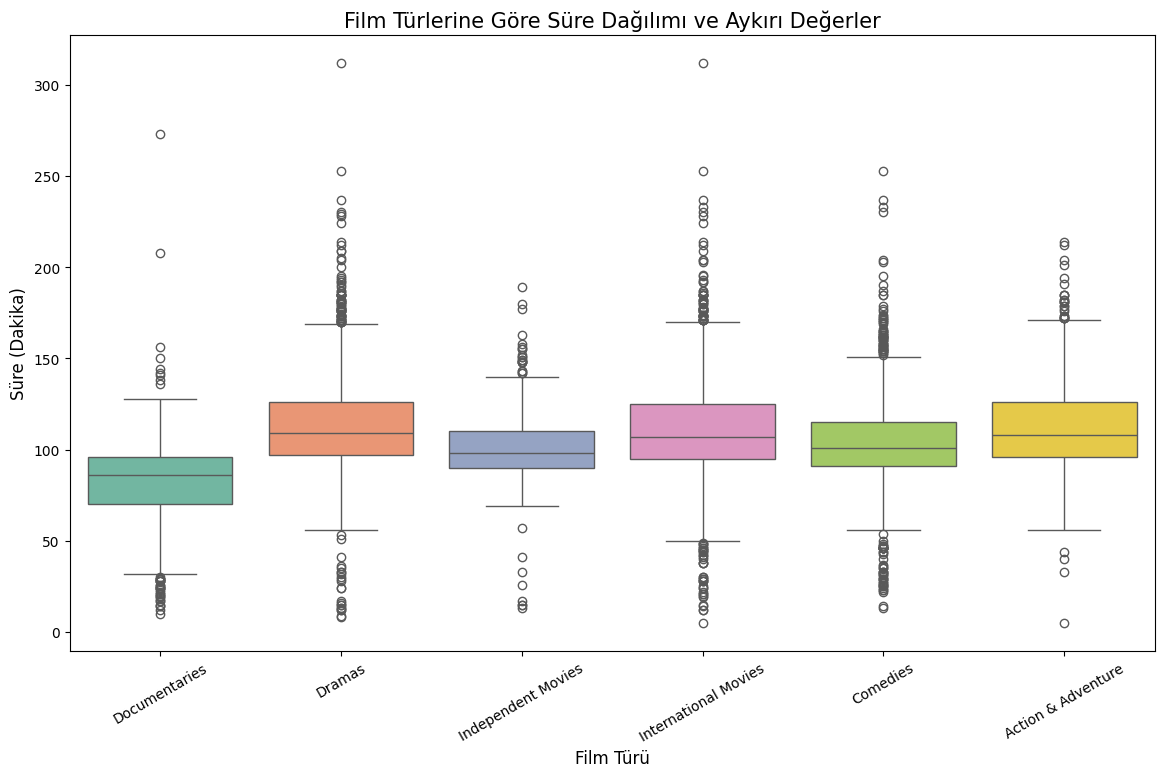

In [19]:

df_movies = df[df['type'] == 'Movie'].copy()
df_movies.dropna(subset=['duration'], inplace=True)
df_movies['duration_num'] = df_movies['duration'].str.extract('(\d+)').astype(int)

# En popüler 6 türü seçelim (Birden fazla türü olanları ayıralım)
df_genres = df_movies.copy()
df_genres['listed_in'] = df_genres['listed_in'].str.split(', ')
df_genres = df_genres.explode('listed_in')
top_6_genres = df_genres['listed_in'].value_counts().head(6).index
df_plot = df_genres[df_genres['listed_in'].isin(top_6_genres)]

# Görselleştirme: Kutu Grafiği (Box Plot)
plt.figure(figsize=(14, 8))
sns.boxplot(x='listed_in', y='duration_num', data=df_plot, palette='Set2')

plt.title('Film Türlerine Göre Süre Dağılımı ve Aykırı Değerler', fontsize=15)
plt.xlabel('Film Türü', fontsize=12)
plt.ylabel('Süre (Dakika)', fontsize=12)
plt.xticks(rotation=30)
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10852\3977534803.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='listed_in', y='seasons_num', data=df_tv_plot, palette='Pastel1')


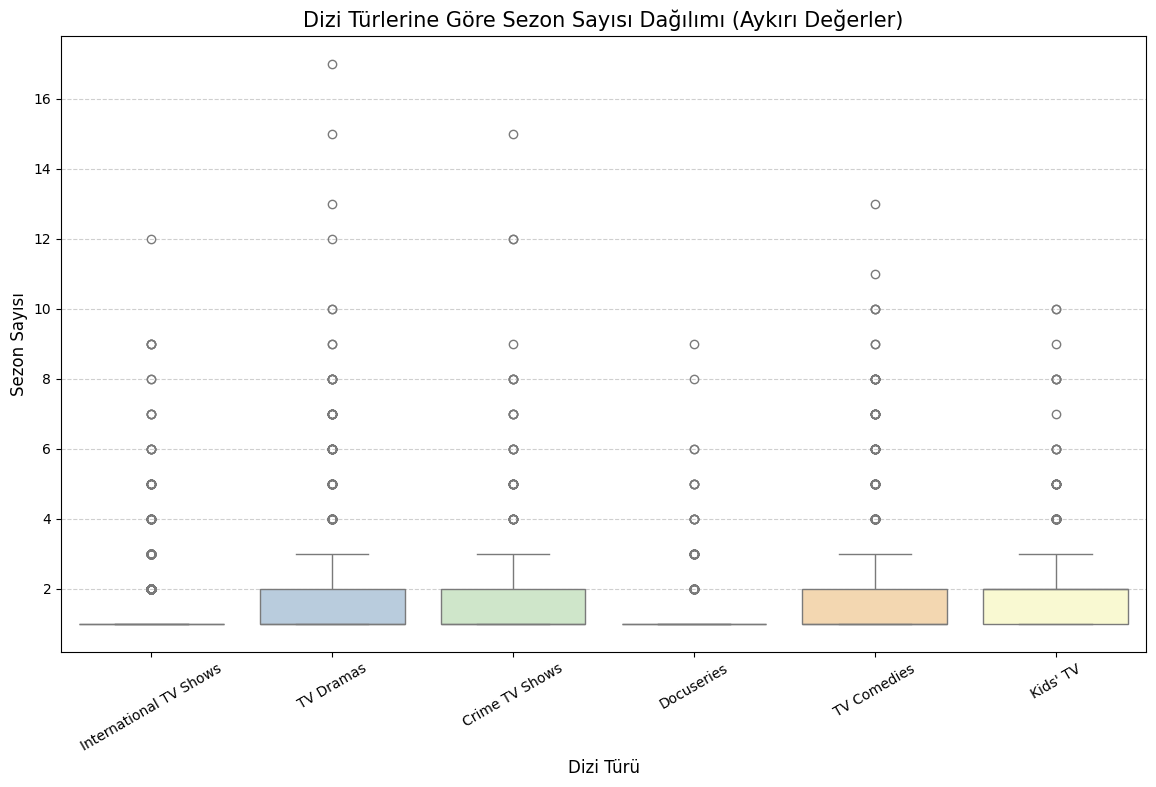

In [20]:
# 1. Veri Hazırlama: Sadece dizileri (TV Show) filtrele
df_tv = df[df['type'] == 'TV Show'].copy()
df_tv.dropna(subset=['duration'], inplace=True)

# 2. Sezon Sayısını Çekme (Örn: "2 Seasons" -> 2)
df_tv['seasons_num'] = df_tv['duration'].str.extract('(\d+)').astype(int)

# 3. En popüler 6 dizi türünü seçelim (Türleri patlatarak)
df_tv_genres = df_tv.copy()
df_tv_genres['listed_in'] = df_tv_genres['listed_in'].str.split(', ')
df_tv_genres = df_tv_genres.explode('listed_in')

top_6_tv_genres = df_tv_genres['listed_in'].value_counts().head(6).index
df_tv_plot = df_tv_genres[df_tv_genres['listed_in'].isin(top_6_tv_genres)]

# 4. Görselleştirme: Kutu Grafiği (Box Plot)
plt.figure(figsize=(14, 8))
sns.boxplot(x='listed_in', y='seasons_num', data=df_tv_plot, palette='Pastel1')

plt.title('Dizi Türlerine Göre Sezon Sayısı Dağılımı (Aykırı Değerler)', fontsize=15)
plt.xlabel('Dizi Türü', fontsize=12)
plt.ylabel('Sezon Sayısı', fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()